In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmcrameri as cm
from collections import defaultdict
import cmocean as cmc

import cloud_filtering.training.config as config
import cloud_filtering.plotting.utils as plot_utils

plt.style.use('../plotstyling.mplstyle')

In [3]:
filepath = "../../../DataStorage/AWS/for_cloud_filtering/test_set_retrievals/"
variant_filenames = {
    variant: filepath + f"cloud_signal_test_set_retrievals_{variant}_20260309.nc" for variant in config.VARIANTS
}

In [4]:
retrieval_distribution_ds = xr.open_dataset("../../../DataStorage/AWS/for_cloud_filtering/obs_distributions/cloud_signal_distributions_retrievals_on_obs_2026-03-19.nc")


In [5]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
db_ds = xr.open_dataset(db_filename)


In [6]:
db_ds.Latitude

<xarray.DataArray 'Latitude' (number: 7826236)> Size: 63MB
[7826236 values with dtype=float64]
Dimensions without coordinates: number
Attributes:
    units:      degrees
    long_name:  Latitude

In [7]:

Ta_bins = np.linspace(100, 300, 50)
deviation_bins = np.linspace(-30, 30, 101)  # bins used for calculating distributions of predicted error
cloud_signal_bins = np.linspace(-15, 160, 176)
cloud_signal_bins_narrower = np.linspace(-2, 10, 121)
lat_bins = np.arange(-90, 91, 1)
lon_bins = np.arange(-180, 181, 1)

lat_centres = 0.5 * (lat_bins[:-1] + lat_bins[1:])
lon_centres = 0.5 * (lon_bins[:-1] + lon_bins[1:])
deviation_bins_centre = deviation_bins[:-1] + np.diff(deviation_bins) / 2
cloud_signal_bins_centre = cloud_signal_bins[:-1] + np.diff(cloud_signal_bins) / 2
cloud_signal_bins_narrower_centre = cloud_signal_bins_narrower[:-1] + np.diff(cloud_signal_bins_narrower) / 2

blues = plt.cm.Blues(np.linspace(0.3, 0.9, 6))
oranges = plt.cm.Oranges(np.linspace(0.9, 0.3, 4))

In [8]:
BASE_INPUT_VARIABLES = [
    "Ta_Allsky_AWS31",
    "Ta_Allsky_AWS32",
    "Ta_Allsky_AWS33",
    "Ta_Allsky_AWS34",
    "Ta_Allsky_AWS35",
    "Ta_Allsky_AWS36",
    "Ta_Allsky_AWS41",
    "Ta_Allsky_AWS42",
    "Ta_Allsky_AWS43",
    "Ta_Allsky_AWS44",
    "MirrorAngle",
]

BASE_OUTPUT_VARIABLES = [
    "CloudSignal_AWS31",
    "CloudSignal_AWS32",
    "CloudSignal_AWS33",
    "CloudSignal_AWS34",
    "CloudSignal_AWS35",
    "CloudSignal_AWS36",
    "CloudSignal_AWS41",
    "CloudSignal_AWS42",
    "CloudSignal_AWS43",
    "CloudSignal_AWS44",
]


VARIANTS = {
    "aws31_36": [],
    "aws32_36": ["Ta_Allsky_AWS31"],
    "aws33_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32"],
    "aws34_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32", "Ta_Allsky_AWS33", "Ta_Allsky_AWS44"],
    "aws35_36": ["Ta_Allsky_AWS31", "Ta_Allsky_AWS32", "Ta_Allsky_AWS33", "Ta_Allsky_AWS44", "Ta_Allsky_AWS34", "Ta_Allsky_AWS43"],
}


def get_input_variables(tag):
    """Return input list for a given variant."""
    drop = set(VARIANTS[tag])
    inputs = [v for v in BASE_INPUT_VARIABLES if v not in drop]

    # never train if only AWS36 remains from AWS3x
    #aws3x = [v for v in inputs if v.startswith("Ta_Allsky_AWS3")]
    #if aws3x == ["Ta_Allsky_AWS36"]:
    #    raise ValueError("Invalid variant: only AWS36 remaining.")

    return inputs

def get_output_variables(tag):
    """Return input list for a given variant."""
    drop = set(VARIANTS[tag])
    print(drop)
    outputs = []
    for var in BASE_OUTPUT_VARIABLES:
        print(var)
        var_allsky = f"Ta_Allsky_AWS{var[-2:]}"
        if var_allsky not in drop:
            outputs.append(var)

    return outputs


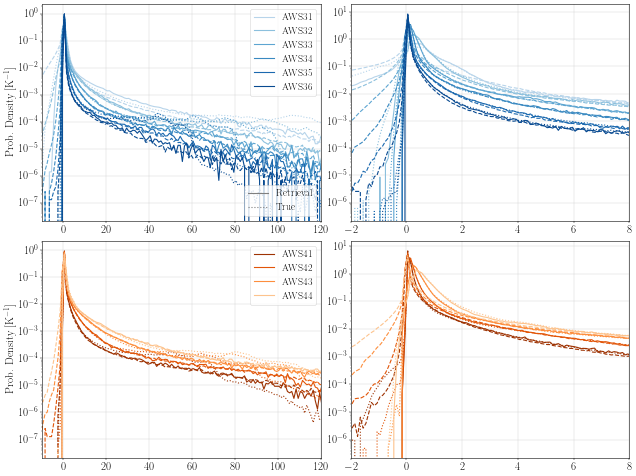

In [10]:

channel_mean_data = defaultdict(list)
channel_true_data = defaultdict(list)

for variant in config.VARIANTS:
    ds = xr.open_dataset(variant_filenames[variant])
    variant_inputs = list(set(config.BASE_INPUT_VARIABLES[:-1]).difference(config.VARIANTS[variant]))
    variant_outputs = np.sort([f'CloudSignal_{var[-5:]}' for var in variant_inputs])

    for var in variant_outputs:
        channel = var[-5:]
        channel_mean_data[channel].append(ds[f"CloudSignal_{channel}_mean"].values)
        channel_true_data[channel].append(ds[f"CloudSignal_{channel}_true"].values)

    ds.close()

# Concatenate across variants
channel_mean_data = {ch: np.concatenate(arrays) for ch, arrays in channel_mean_data.items()}
channel_true_data = {ch: np.concatenate(arrays) for ch, arrays in channel_true_data.items()}

# --- Pass 2: plot one histogram per channel ---
all_channels = np.sort(list(channel_mean_data.keys()))

fig, axes_2d = plt.subplots(2, 2, figsize=(16, 12))

blues_i = 0
oranges_i = 0

for var in [f'CloudSignal_{ch}' for ch in all_channels]:
    channel = var[-5:]
    channel_id = int(var[-2:])

    mean = channel_mean_data[channel]
    true = db_ds[f"Ta_Clearsky_{channel}"].values - db_ds[f"Ta_Allsky_{channel}"].values

    test_retrieval_distribution, _ = np.histogram(mean, bins=cloud_signal_bins, density=True)
    test_retrieval_distribution_narrower, _ = np.histogram(mean, bins=cloud_signal_bins_narrower, density=True)
    true_distribution, _ = np.histogram(true, bins=cloud_signal_bins, density=True)
    true_distribution_narrower, _ = np.histogram(true, bins=cloud_signal_bins_narrower, density=True)

    obs_retrieval_distribution, _ = np.histogram(mean, bins=cloud_signal_bins, density=True)
    test_retrieval_distribution_narrower, _ = np.histogram(mean, bins=cloud_signal_bins_narrower, density=True)

    obs_retrieval_distribution = retrieval_distribution_ds[f"Ta_CloudSignal_{channel}_hist_all"].values
    obs_retrieval_distribution_narrower = retrieval_distribution_ds[f"Ta_CloudSignal_{channel}_hist_narrower_all"].values

    if channel_id < 40:
        color = blues[blues_i]
        row = 0
        blues_i += 1
    else:
        color = oranges[oranges_i]
        row = 1
        oranges_i += 1

    axes_2d[row, 0].plot(cloud_signal_bins_centre, test_retrieval_distribution, color=color, label=channel, lw=2)
    axes_2d[row, 1].plot(cloud_signal_bins_narrower_centre, test_retrieval_distribution_narrower, color=color, lw=2)
    axes_2d[row, 0].plot(cloud_signal_bins_centre, true_distribution, color=color, ls="--", lw=2)
    axes_2d[row, 1].plot(cloud_signal_bins_narrower_centre, true_distribution_narrower, color=color, ls="--", lw=2)

    axes_2d[row, 0].plot(cloud_signal_bins_centre, obs_retrieval_distribution, color=color, ls=":", lw=2)
    axes_2d[row, 1].plot(cloud_signal_bins_narrower_centre, obs_retrieval_distribution_narrower, color=color, ls=":", lw=2)



axes_2d[0, 0].set_ylabel(r"Prob. Density [K$^{-1}$]")
axes_2d[1, 0].set_ylabel(r"Prob. Density [K$^{-1}$]")

axes_2d[0, 0].set_xlim([-10, 120])
axes_2d[1, 0].set_xlim([-10, 120])
axes_2d[0, 1].set_xlim([-2, 8])
axes_2d[1, 1].set_xlim([-2, 8])

#axes_2d[1, 1].set_xscale("log")
#axes_2d[0, 1].set_xscale("log")

for ax_row in axes_2d:
    for ax in ax_row:
        #ax.set_ylim([1e-5, 2e0])
        ax.set_yscale("log")
        ax.grid(color="lightgrey")

channel_legend = axes_2d[0, 0].legend(loc="upper right")
style_handles = [
    Line2D([0], [0], color="grey", lw=2, linestyle="-", label="Retrieval"),
    Line2D([0], [0], color="grey", lw=2, linestyle=":", label="True"),
]
style_legend = axes_2d[0, 0].legend(handles=style_handles, loc="lower right")
axes_2d[0, 0].add_artist(channel_legend)
axes_2d[1, 0].legend(loc="upper right")

fig.tight_layout()
#plt.savefig(f"../figures/test_set_retrievals/test_set_retrieval_distributions_all_variants.png",
#            dpi=300, facecolor="white", bbox_inches="tight")

In [11]:
# --- Pass 1: accumulate data across all variants ---
channel_mean_data = defaultdict(list)
channel_true_data = defaultdict(list)
channel_lat_data  = defaultdict(list)  # <-- add this

for variant in config.VARIANTS:
    ds = xr.open_dataset(variant_filenames[variant])
    variant_inputs  = list(set(config.BASE_INPUT_VARIABLES[:-1]).difference(config.VARIANTS[variant]))
    variant_outputs = np.sort([f'CloudSignal_{var[-5:]}' for var in variant_inputs])

    for var in variant_outputs:
        channel = var[-5:]
        channel_mean_data[channel].append(ds[f"CloudSignal_{channel}_mean"].values)
        channel_true_data[channel].append(ds[f"CloudSignal_{channel}_true"].values)
        channel_lat_data[channel].append(ds["Latitude"].values)           # <-- add this

    ds.close()

channel_mean_data = {ch: np.concatenate(v) for ch, v in channel_mean_data.items()}
channel_true_data = {ch: np.concatenate(v) for ch, v in channel_true_data.items()}
channel_lat_data  = {ch: np.concatenate(v) for ch, v in channel_lat_data.items()}  # <-- add this

In [12]:
channels_3x = np.sort([ch for ch in all_channels if int(ch[-2:]) < 40])
channels_4x = np.sort([ch for ch in all_channels if int(ch[-2:]) >= 40])
n_cols = max(len(channels_3x), len(channels_4x) + 2)

lat_regions = {
    "all":       lambda lat: np.ones(len(lat), dtype=bool),
    "30S_30N":   lambda lat: np.abs(lat) <= 30,
    "60S_60N":   lambda lat: np.abs(lat) <= 60,
    "only_midlats": lambda lat: (np.abs(lat) > 30) & (np.abs(lat) <= 60),
    "only_highlats": lambda lat: (np.abs(lat) > 60),
}

for lat_label, lat_mask_fn in lat_regions.items():
    for fig_label, bins, bins_centre, xlim in [
        ("wide",     cloud_signal_bins,          cloud_signal_bins_centre,          (-10, 120)),
        ("narrower", cloud_signal_bins_narrower, cloud_signal_bins_narrower_centre, (-2,  8)),
    ]:
        fig, axes_2d = plt.subplots(2, n_cols, figsize=(n_cols * 3.5, 8), sharey=True)

        # --- Top row: 3X channels ---
        for col, channel in enumerate(channels_3x):
            ax = axes_2d[0, col]

            lat_mask  = lat_mask_fn(channel_lat_data[channel])
            db_lat    = db_ds["Latitude"].values
            db_mask   = lat_mask_fn(db_lat)

            mean = channel_mean_data[channel][lat_mask]
            true = (db_ds[f"Ta_Clearsky_{channel}"].values - db_ds[f"Ta_Allsky_{channel}"].values)[db_mask]

            obs_key_suffix = "_narrower" if fig_label == "narrower" else ""
            dist_test, _ = np.histogram(mean, bins=bins, density=True)
            dist_true, _ = np.histogram(true, bins=bins, density=True)
            obs_dist = retrieval_distribution_ds[f"Ta_CloudSignal_{channel}_hist{obs_key_suffix}_{lat_label}"].values

            show_label = col == 0
            ax.stairs(dist_true, bins, fill=True, color="lightgrey", alpha=0.4, label="Database" if show_label else None)
            ax.plot(bins_centre, obs_dist,  color=blues[-2], lw=2,       label="Retrieval (obs)" if show_label else None)
            ax.plot(bins_centre, dist_test, color=blues[0],  lw=2, ls="--", label="Retrieval (test set)" if show_label else None)
            ax.set_title(channel)
            ax.set_xlim(xlim)
            ax.set_yscale("log")
            ax.grid(color="lightgrey")
            if show_label:
                ax.legend(loc="upper right", fontsize=12)

        for col in range(len(channels_3x), n_cols):
            axes_2d[0, col].set_visible(False)

        # --- Bottom row: 4X channels reversed ---
        for j, channel in enumerate(channels_4x[::-1]):
            col = 2 + j
            ax = axes_2d[1, col]

            lat_mask = lat_mask_fn(channel_lat_data[channel])
            db_lat   = db_ds["Latitude"].values
            db_mask  = lat_mask_fn(db_lat)

            mean = channel_mean_data[channel][lat_mask]
            true = channel_true_data[channel][lat_mask]

            obs_key_suffix = "_narrower" if fig_label == "narrower" else ""
            dist_test, _ = np.histogram(mean, bins=bins, density=True)
            dist_true, _ = np.histogram(true, bins=bins, density=True)
            obs_dist = retrieval_distribution_ds[f"Ta_CloudSignal_{channel}_hist{obs_key_suffix}_{lat_label}"].values

            show_label = j == 0
            ax.stairs(dist_true, bins, fill=True, color="lightgrey", alpha=0.4, label="Database" if show_label else None)
            ax.plot(bins_centre, obs_dist,  color=oranges[0],  lw=2,       label="Retrieval (obs)" if show_label else None)
            ax.plot(bins_centre, dist_test, color=oranges[-2], lw=2, ls="--", label="Retrieval (test set)" if show_label else None)
            ax.set_title(channel)
            ax.set_xlim(xlim)
            ax.set_ylim([1e-6, 1e1])
            ax.set_yscale("log")
            ax.grid(color="lightgrey")
            if show_label:
                ax.legend(loc="upper right", fontsize=12)

        for col in list(range(2)) + list(range(2 + len(channels_4x), n_cols)):
            axes_2d[1, col].set_visible(False)

        axes_2d[0, 0].set_ylabel(r"Prob. Density [K$^{-1}$]")
        axes_2d[1, 2].set_ylabel(r"Prob. Density [K$^{-1}$]")
        fig.suptitle(f"Latitude: {lat_label.replace('_', ' ').title()}", fontsize=20, y=1.01)

        fig.tight_layout()
        plt.savefig(
            f"../figures/retrievals_on_obs/distributions/overall_distributions_{fig_label}_{lat_label}.png",
            dpi=300, facecolor="white", bbox_inches="tight",
        )
        plt.close()